# Trabalho Prático de Mineração de Dados
## Spaceship Titanic – Classificação Binária
### Competição Kaggle: [Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic)

---

**Contexto do problema**

Em 2912, a nave interestelar *Spaceship Titanic* colidiu com uma anomalia espaço-temporal, resultando no desaparecimento de quase metade dos seus passageiros. A hipótese formulada é de que estes indivíduos foram transportados para uma dimensão alternativa. A partir dos registros recuperados do sistema computacional danificado da nave, o objetivo deste trabalho é construir um modelo capaz de **prever, para cada passageiro, se ele foi ou não transportado** — configurando, portanto, um problema de classificação binária sobre a variável `Transported` (valores `True` ou `False`). A métrica de avaliação adotada pela competição é a acurácia, definida como a proporção de previsões corretas sobre o total de instâncias.

**Estrutura do experimento**

O desenvolvimento do projeto segue o roteiro descrito abaixo, respeitando a sequência canônica de um projeto de mineração de dados supervisionado:

1. Importação de bibliotecas
2. Carregamento dos dados
3. Análise exploratória (EDA)
4. Engenharia de atributos
5. Pré-processamento
6. Treinamento e comparação de modelos
7. Otimização de hiperparâmetros
8. Análise do melhor modelo
9. Geração do arquivo de submissão


## 1. Importação de Bibliotecas

Nesta seção, carregamos todas as dependências necessárias ao longo do projeto. A tabela a seguir descreve a finalidade de cada biblioteca utilizada.

| Biblioteca | Finalidade |
|---|---|
| `pandas` | Manipulação e análise de dados em formato tabular (DataFrames) |
| `numpy` | Operações numéricas sobre arrays de forma eficiente |
| `matplotlib` / `seaborn` | Construção de visualizações estáticas |
| `scipy` | Testes estatísticos, incluindo o teste qui-quadrado de independência |
| `scikit-learn` | Pré-processamento, treinamento e avaliação de modelos de aprendizado de máquina |

A escolha do scikit-learn como framework central se justifica pela sua interface padronizada: todo estimador expõe os métodos `.fit()` e `.predict()`, o que torna a comparação entre algoritmos direta e reprodutível.


In [ ]:
# Manipulação e cálculo
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Testes estatísticos
from scipy.stats import chi2_contingency

# Configurações globais de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='Set2')

# Scikit-learn – Pré-processamento
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Scikit-learn – Seleção de modelos e validação cruzada
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    RandomizedSearchCV      # Busca aleatória de hiperparâmetros
)

# Scikit-learn – Classificadores
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn – Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,         # Acurácia = acertos / total
    classification_report,  # Precisão, recall e F1 por classe
    confusion_matrix,
    roc_auc_score,          # Área sob a curva ROC
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')


## 2. Carregamento dos Dados

A competição disponibiliza três arquivos distintos:

- **`train.csv`** — aproximadamente 8.700 passageiros com o rótulo `Transported` presente; utilizado integralmente para o ajuste e a avaliação dos modelos.
- **`test.csv`** — aproximadamente 4.300 passageiros sem rótulo; sobre este conjunto geramos as previsões a serem submetidas à plataforma Kaggle.
- **`sample_submission.csv`** — exemplo do formato de saída esperado pela competição.

Os arquivos estão armazenados no Google Drive e são acessados via montagem do sistema de arquivos no ambiente Google Colab.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_PATH = "/content/drive/MyDrive/Mineração de Dados/Trabalho_Elian_Hugo/spaceship-titanic"

train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
test_df  = pd.read_csv(f"{BASE_PATH}/test.csv")
sample_submission = pd.read_csv(f"{BASE_PATH}/sample_submission.csv")

'''
train_df = pd.read_csv(f"train.csv")
test_df  = pd.read_csv(f"test.csv")
sample_submission = pd.read_csv("sample_submission.csv")
'''
print(f"Treino : {train_df.shape[0]:,} linhas × {train_df.shape[1]} colunas")
print(f"Teste  : {test_df.shape[0]:,} linhas × {test_df.shape[1]} colunas")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Treino : 8,693 linhas × 14 colunas
Teste  : 4,277 linhas × 13 colunas


## 3. Análise Exploratória de Dados (EDA)

A Análise Exploratória de Dados é a etapa que fundamenta todas as decisões de modelagem subsequentes. Por meio dela, identificamos a estrutura e os tipos de cada atributo, quantificamos os valores ausentes, detectamos padrões distribucionais e mensuramos a associação entre as variáveis independentes e a variável-alvo. Omitir esta etapa aumenta o risco de se aplicar transformações inadequadas ou de ignorar informações relevantes que poderiam melhorar o desempenho do modelo.

### 3.1 Visão Geral do Conjunto de Dados

Inspecionamos as primeiras linhas, os tipos de dados e as estatísticas descritivas das colunas numéricas para obter uma compreensão inicial da estrutura dos dados.


In [ ]:
# Inspeção das primeiras linhas: permite verificar o formato e os valores típicos de cada coluna
print("=== Primeiras 5 linhas do conjunto de treino ===")
train_df.head()


=== Primeiras 5 linhas do conjunto de treino ===


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
# Tipos de dados e contagem de valores não nulos: revela onde existem valores ausentes
print("=== Informações sobre colunas e valores ausentes ===")
train_df.info()


=== Informações sobre colunas e valores ausentes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [ ]:
# Estatísticas descritivas: média, desvio padrão, percentis e extremos de cada coluna numérica
# .describe() calcula estatísticas resumidas das colunas NUMÉRICAS:
# count   = quantos valores não nulos
# mean    = média
# std     = desvio padrão (quanto os valores variam)
# min/max = valores mínimo e máximo
# 25%/50%/75% = percentis (mediana é o 50%)
print("=== Estatísticas descritivas ===")
train_df.describe().round(2)


=== Estatísticas descritivas ===


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.00,8512.00,8510.00,8485.00,8510.00,8505.00
mean,28.83,224.69,458.08,173.73,311.14,304.85
std,14.49,666.72,1611.49,604.70,1136.71,1145.72
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,19.00,0.00,0.00,0.00,0.00,0.00
50%,27.00,0.00,0.00,0.00,0.00,0.00
75%,38.00,47.00,76.00,27.00,59.00,46.00
max,79.00,14327.00,29813.00,23492.00,22408.00,24133.00


### 3.2 Análise da Variável Alvo (`Transported`)

Antes de qualquer modelagem, verificamos o balanceamento entre as classes. Em conjuntos com forte desbalanceamento — por exemplo, 95% de instâncias negativas e 5% positivas —, um classificador ingênuo que prevê sempre a classe majoritária alcança acurácia elevada sem qualquer utilidade prática. Nesse cenário, a acurácia deixa de ser uma métrica informativa e devem-se adotar técnicas de reamostragem ou pesos diferenciados por classe. A verificação do balanceamento determina, portanto, se a métrica de avaliação adotada é apropriada.


=== Distribuição da variável alvo ===
  Transportado: 4,378 passageiros (50.4%)
  Não Transportado: 4,315 passageiros (49.6%)


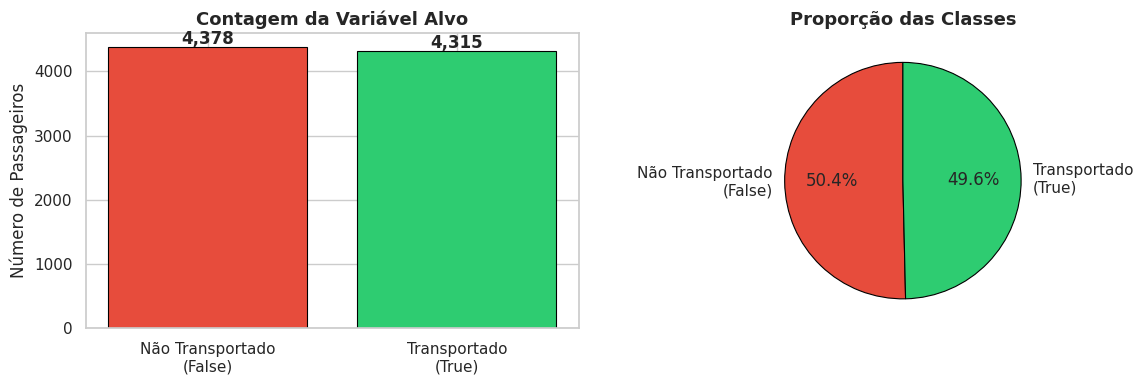

In [ ]:
target_counts = train_df['Transported'].value_counts()
target_pct    = train_df['Transported'].value_counts(normalize=True) * 100

print("=== Distribuição da variável alvo ===")
for label, count, pct in zip(target_counts.index, target_counts.values, target_pct.values):
    status = "Transportado" if label else "Não Transportado"
    print(f"  {status}: {count:,} passageiros ({pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras com contagem
axes[0].bar(
    ['Não Transportado\n(False)', 'Transportado\n(True)'],
    target_counts.values,
    color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8
)
axes[0].set_title('Contagem da Variável Alvo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Passageiros')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=12, fontweight='bold')

# Gráfico de pizza
axes[1].pie(
    target_counts.values,
    labels=['Não Transportado\n(False)', 'Transportado\n(True)'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[1].set_title('Proporção das Classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### 3.3 Análise de Valores Ausentes

Valores ausentes surgem quando registros não foram coletados ou se perderam. A maioria dos algoritmos de aprendizado de máquina não aceita entradas com valores nulos, exigindo uma estratégia explícita de tratamento. As abordagens adotadas neste trabalho são:

| Tipo de atributo | Estratégia | Justificativa |
|---|---|---|
| Numérico (geral) | Substituição pela mediana | A mediana é robusta a valores extremos (*outliers*), que são comuns nos atributos de gasto deste conjunto |
| Categórico | Substituição pela moda | O valor mais frequente representa a categoria dominante e minimiza a distorção da distribuição original |
| Gastos (`RoomService`, `FoodCourt` etc.) | Substituição por zero | Passageiros em *CryoSleep* não têm acesso aos serviços da nave; a ausência de registro é equivalente a gasto nulo |

Avaliamos o volume e a proporção de valores ausentes por coluna antes de definir a estratégia.


=== Valores Ausentes no Conjunto de Treino ===
              Ausentes  Percentual (%)
CryoSleep          217            2.50
ShoppingMall       208            2.39
VIP                203            2.34
HomePlanet         201            2.31
Name               200            2.30
Cabin              199            2.29
VRDeck             188            2.16
FoodCourt          183            2.11
Spa                183            2.11
Destination        182            2.09
RoomService        181            2.08
Age                179            2.06


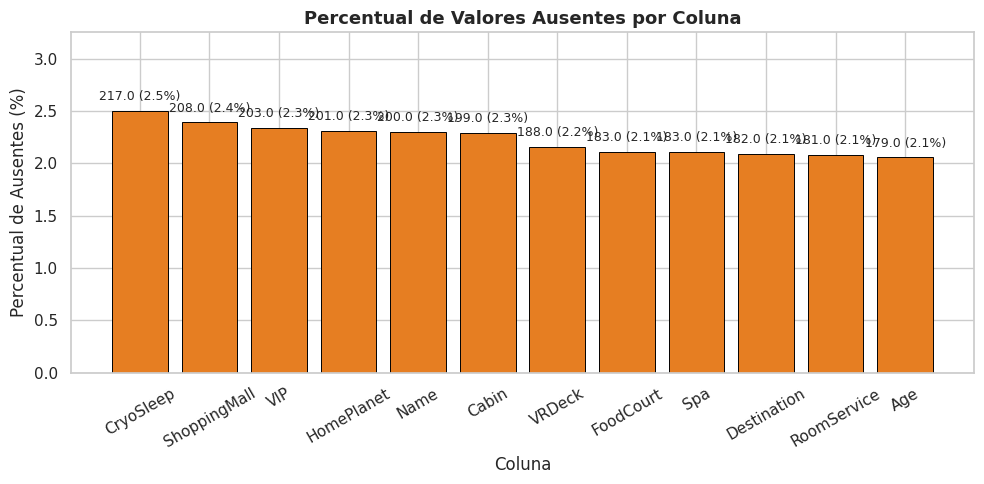

In [ ]:
# Cálculo absoluto e percentual de valores ausentes por coluna
ausentes = train_df.isnull().sum()
ausentes_pct = (ausentes / len(train_df) * 100).round(2)
df_ausentes = pd.DataFrame({'Ausentes': ausentes, 'Percentual (%)': ausentes_pct})
df_ausentes = df_ausentes[df_ausentes['Ausentes'] > 0].sort_values('Ausentes', ascending=False)

print("=== Valores Ausentes no Conjunto de Treino ===")
print(df_ausentes.to_string())

# Gráfico de barras simples: percentual de ausentes por coluna
fig, ax = plt.subplots(figsize=(10, 5))

barras = ax.bar(
    df_ausentes.index,
    df_ausentes['Percentual (%)'],
    color='#e67e22', edgecolor='black', linewidth=0.7
)
ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentual de Ausentes (%)')
ax.set_xlabel('Coluna')
ax.set_ylim(0, df_ausentes['Percentual (%)'].max() * 1.3)
ax.tick_params(axis='x', rotation=30)

# Adicionar os valores no topo de cada barra
for barra, (col, row) in zip(barras, df_ausentes.iterrows()):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.1,
        f"{row['Ausentes']} ({row['Percentual (%)']:.1f}%)",
        ha='center', fontsize=9
    )

plt.tight_layout()
plt.show()


### 3.4 Distribuição das Variáveis Numéricas

Analisamos os histogramas das variáveis numéricas para identificar assimetria, concentração de valores e a presença de zeros em excesso. A linha tracejada vermelha indica a média e a verde indica a mediana. Quando a média supera substancialmente a mediana, a distribuição apresenta assimetria positiva — situação típica de atributos de consumo, em que a maioria dos valores é baixa ou nula e uma minoria de valores muito altos eleva a média. Essa característica orienta a escolha da mediana, em vez da média, como estimativa de imputação.


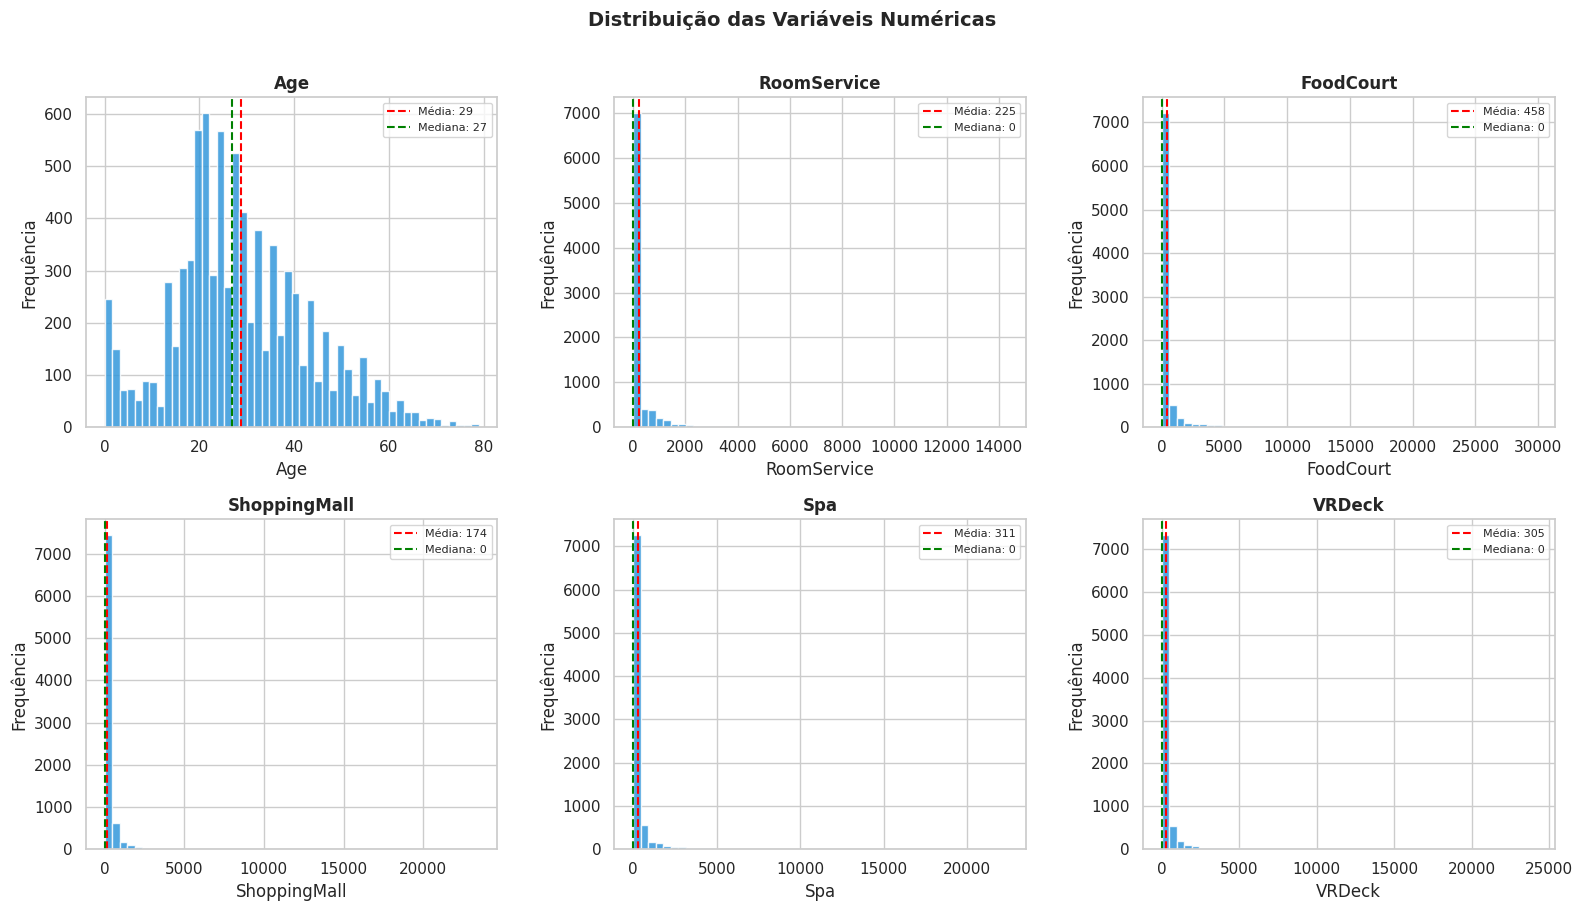

In [ ]:
num_cols_plot = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(num_cols_plot):
    dados = train_df[col].dropna()
    axes[i].hist(dados, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i].axvline(dados.mean(),   color='red',   linestyle='--', linewidth=1.5,
                    label=f'Média: {dados.mean():.0f}')
    axes[i].axvline(dados.median(), color='green', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {dados.median():.0f}')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


As colunas de gasto têm muitos zeros e poucos valores muito altos. A média (vermelho) está bem acima da mediana (verde) nessas colunas – isso indica distribuição assimétrica causada por poucos passageiros que gastaram muito.

### 3.5 Relação entre Gastos e Transporte

Para cada serviço disponível na nave, calculamos a proporção de passageiros com gasto igual a zero, segmentando os grupos `Transported = True` e `Transported = False`. Essa análise permite verificar se existe uma diferença sistemática no padrão de consumo entre passageiros transportados e não transportados — o que configuraria poder preditivo nos atributos de gasto.

A hipótese subjacente é que passageiros em *CryoSleep* não têm condições de consumir serviços, de modo que gastos nulos seriam um indicador indireto do estado criogênico e, consequentemente, do transporte.


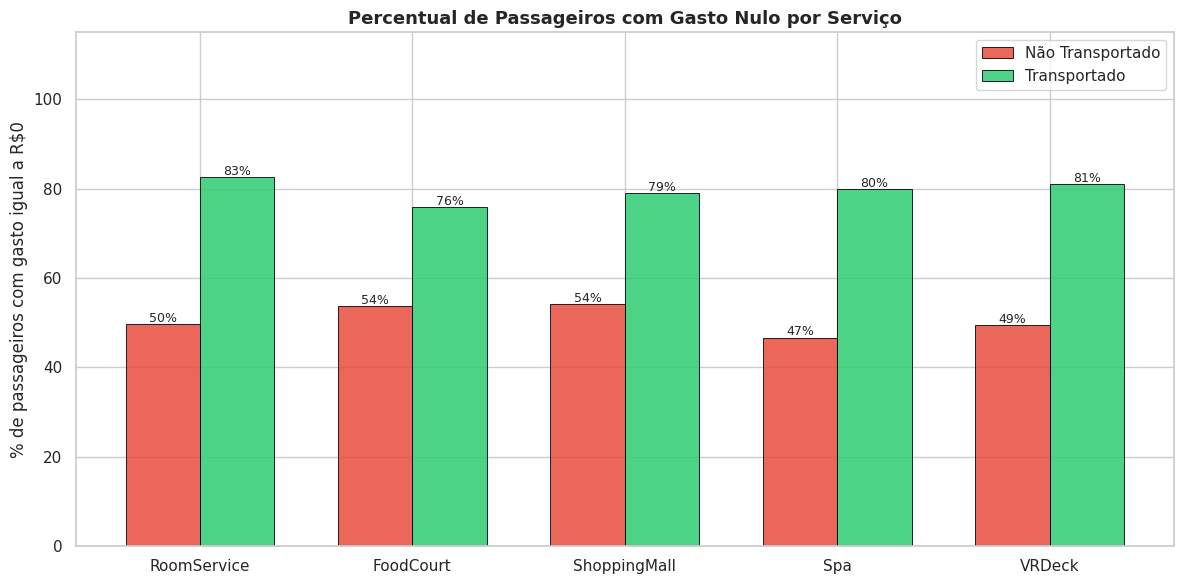

In [ ]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Proporção de passageiros com gasto zero por grupo e serviço
zero_nao = [] # % com gasto zero entre NÃO transportados
zero_sim = [] # % com gasto zero entre TRANSPORTADOS

for col in spend_cols:
    grupo_nao = train_df.loc[train_df['Transported'] == False, col].fillna(0)
    grupo_sim = train_df.loc[train_df['Transported'] == True,  col].fillna(0)
    zero_nao.append((grupo_nao == 0).mean() * 100)
    zero_sim.append((grupo_sim == 0).mean() * 100)

x = range(len(spend_cols))
largura = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

barras1 = ax.bar([i - largura/2 for i in x], zero_nao, largura,
                  label='Não Transportado', color='#e74c3c',
                  edgecolor='black', linewidth=0.7, alpha=0.85)
barras2 = ax.bar([i + largura/2 for i in x], zero_sim, largura,
                  label='Transportado',     color='#2ecc71',
                  edgecolor='black', linewidth=0.7, alpha=0.85)

# Valores nas barras
for b in list(barras1) + list(barras2):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
            f'{b.get_height():.0f}%', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(spend_cols, fontsize=11)
ax.set_ylabel('% de passageiros com gasto igual a R$0')
ax.set_title('Percentual de Passageiros com Gasto Nulo por Serviço',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


Observamos que existe alguma relação entre não ter gasto nada e ter sido transportado. Possível indicação de que as pessoas que estavam em estado criogênico tinham mais chances de serem transportadas.

### 3.6 Análise das Variáveis Categóricas

Para cada variável categórica, calculamos a taxa de transporte dentro de cada categoria — isto é, a proporção de passageiros classificados como `Transported = True` em cada grupo. Uma variável categórica com poder preditivo apresenta taxas de transporte substancialmente distintas entre suas categorias; uma variável irrelevante exibirá taxas homogêneas.

O gráfico de barras agrupadas, normalizado por linha, permite comparar visualmente essas taxas.


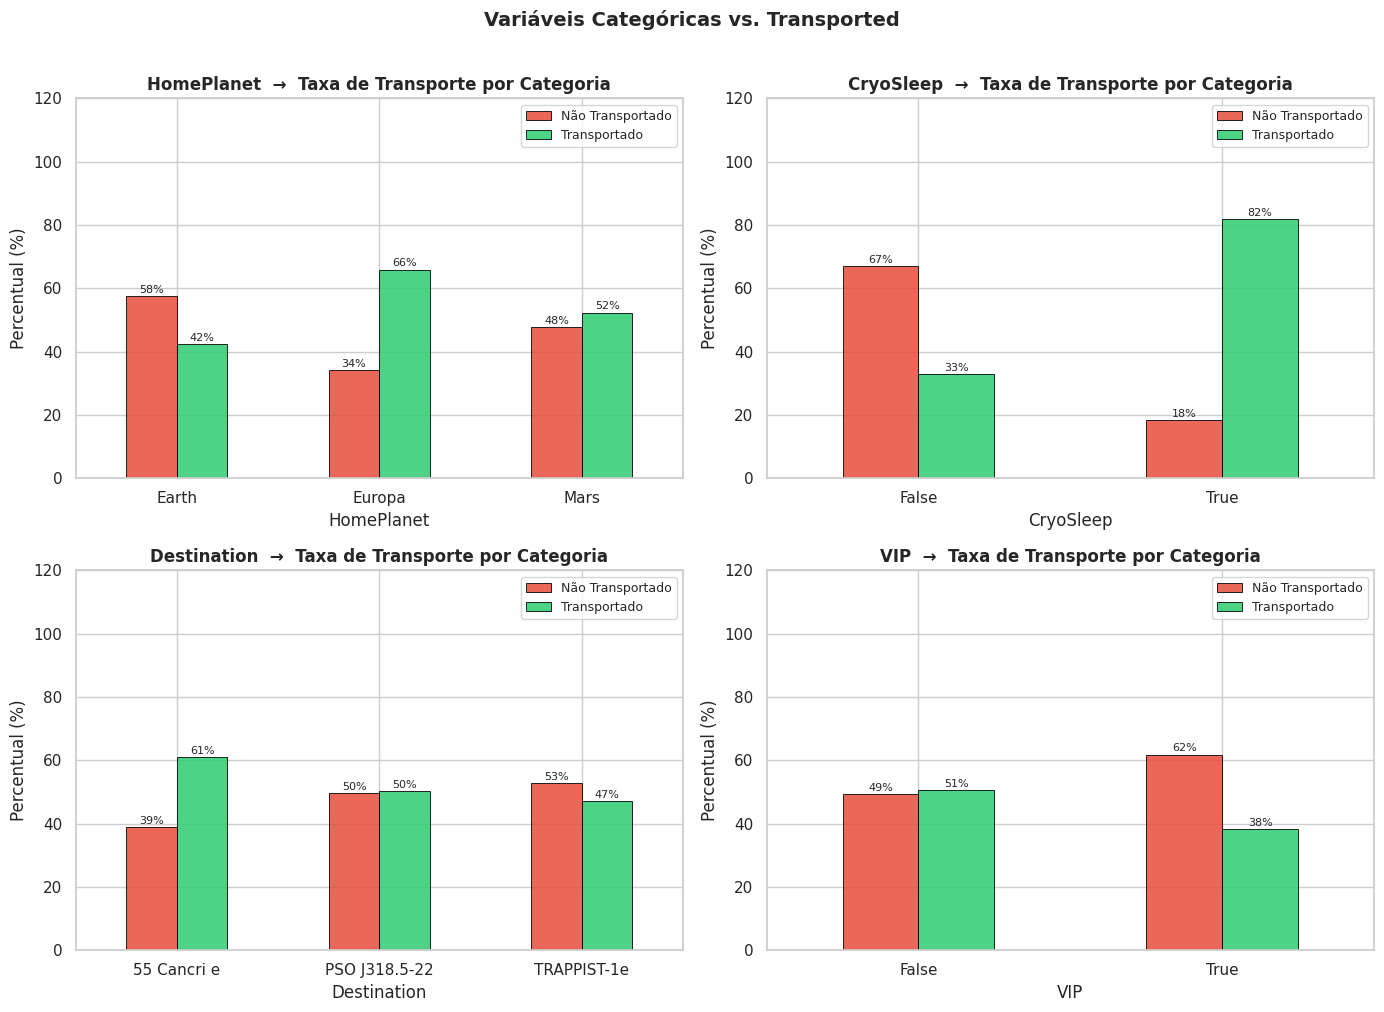

In [ ]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Proporção de transportados e não transportados dentro de cada categoria
    ct = pd.crosstab(train_df[col], train_df['Transported'], normalize='index') * 100
    ct.columns = ['Não Transportado', 'Transportado']
    ct.plot(kind='bar', ax=axes[i], color=['#e74c3c', '#2ecc71'],
            edgecolor='black', linewidth=0.7, alpha=0.85)
    axes[i].set_title(f'{col}  →  Taxa de Transporte por Categoria',
                      fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Percentual (%)')
    axes[i].set_xlabel(col)
    axes[i].legend(loc='upper right', fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].set_ylim(0, 120)

    # Adicionar % em cada barra
    for barra in axes[i].patches:
        if barra.get_height() > 3:
            axes[i].text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 1,
                f'{barra.get_height():.0f}%',
                ha='center', fontsize=8
            )

plt.suptitle('Variáveis Categóricas vs. Transported', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Observamos que as maiores diferenças estão em CryoSleep e HomePlanet, o que pode indicar que elas serão variáveis preditivas uteis.

#### Teste Qui-Quadrado (χ²) — Significância Estatística

A análise visual anterior sugere associação entre as variáveis categóricas e o alvo, mas não garante que as diferenças observadas não sejam fruto do acaso amostral. Para fundamentar estatisticamente essa associação, aplicamos o teste qui-quadrado de independência (χ²) em cada variável categórica.

O teste parte da hipótese nula (H₀) de que a variável categórica e a variável-alvo são independentes entre si. Um p-valor inferior a 0,05 nos permite rejeitar H₀ ao nível de 5% de significância, indicando que a associação observada é estatisticamente significativa e provavelmente não se deve ao acaso.

- **H₀ (hipótese nula):** as variáveis são independentes (sem relação)
- **p-valor < 0.05:** rejeitamos H₀ → há relação real entre a variável e o alvo
- **p-valor ≥ 0.05:** não há evidência de relação


In [ ]:
print(f"{'Variável':<18} {'Chi²':>10} {'p-valor':>12} {'Conclusão'}")
print("-" * 65)

for col in cat_cols:
    tabela = pd.crosstab(train_df[col].fillna('Ausente'), train_df['Transported'])
    chi2, p_val, dof, _ = chi2_contingency(tabela)
    conclusao = "Associação significativa (p < 0.05)" if p_val < 0.05 else "Sem evidência de associação"
    print(f"{col:<18} {chi2:>10.1f} {p_val:>12.2e}  {conclusao}")


Variável                 Chi²      p-valor Conclusão
-----------------------------------------------------------------
HomePlanet              325.0     3.92e-70  Associação significativa (p < 0.05)
CryoSleep              1861.7     0.00e+00  Associação significativa (p < 0.05)
Destination             106.4     6.55e-23  Associação significativa (p < 0.05)
VIP                      12.1     2.36e-03  Associação significativa (p < 0.05)


## 4. Engenharia de Atributos

A engenharia de atributos consiste na criação de novas variáveis a partir das existentes, com o objetivo de tornar explícitas informações que, em sua forma bruta, os algoritmos de aprendizado de máquina não conseguem capturar diretamente.

As transformações realizadas estão descritas na tabela a seguir.

| Transformação | Origem | Justificativa |
|---|---|---|
| Decomposição de `Cabin` em `Deck`, `Cabin_num` e `Side` | Coluna `Cabin` (formato `X/N/Y`) | Cada componente do identificador de cabine pode ter poder preditivo independente |
| Extração do número de grupo (`Group`) e tamanho do grupo (`GroupSize`) | Coluna `PassengerId` (formato `GGGG_PP`) | Passageiros do mesmo grupo tendem a ter destinos e comportamentos similares |
| Indicador de viagem solo (`IsAlone`) | `GroupSize` | Passageiros solitários podem ter perfis de consumo e transporte distintos |
| Gasto total (`TotalSpend`) | Soma das colunas de consumo | Consolida o perfil de gasto em um único atributo numérico |
| Indicador de gasto positivo (`HasSpending`) | `TotalSpend` | Variável binária que separa de forma direta passageiros em *CryoSleep* (gasto nulo) dos demais |

A mesma função de engenharia de atributos é aplicada aos conjuntos de treino e de teste, garantindo consistência entre os conjuntos.


In [ ]:
def feature_engineering(df):
    """
    Aplica as transformações de engenharia de atributos ao DataFrame fornecido.
    Recebe o DataFrame original e retorna o DataFrame com novas colunas.
    """
    df = df.copy()

    # Decomposição da coluna 'Cabin' no formato 'Deck/Cabin_num/Side'
    # Deck: andar da nave (A, B, C, D, E, F, G, T)
    # Side: P = Port (bombordo) ou S = Starboard (estibordo)
    df[['Deck', 'Cabin_num', 'Side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_num'] = pd.to_numeric(df['Cabin_num'], errors='coerce')
    df = df.drop(columns=['Cabin'])

    # Extração do identificador de grupo e cálculo do tamanho do grupo a partir de 'PassengerId'
    # Formato: "0001_01"  →  grupo 1, passageiro 1 do grupo
    df['Group']     = df['PassengerId'].str.split('_').str[0].astype(int)
    df['GroupSize'] = df.groupby('Group')['Group'].transform('count')
    # Indicador binário: passageiro pertence a grupo de tamanho unitário
    df['IsAlone']   = (df['GroupSize'] == 1).astype(int)

    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    # Imputação de zeros nos atributos de gasto: ausência de registro equivale a gasto nulo
    for col in spend_cols:
        df[col] = df[col].fillna(0)

    # Agregação do gasto total e criação do indicador de gasto positivo
    df['TotalSpend']  = df[spend_cols].sum(axis=1)
    df['HasSpending'] = (df['TotalSpend'] > 0).astype(int)

    # Remoção de colunas identificadoras sem valor preditivo
    # PassengerId é só um identificador, sem valor preditivo
    # Name é texto livre, não usaremos neste trabalho
    # Group foi usado para calcular GroupSize, mas não é necessário por si só
    df = df.drop(columns=['PassengerId', 'Name', 'Group'], errors='ignore')

    return df


# Aplicação das transformações nos conjuntos de treino e de teste
train_eng = feature_engineering(train_df)
test_eng  = feature_engineering(test_df)

print(f"Dimensões após engenharia de atributos:")
print(f"  Treino : {train_eng.shape}")
print(f"  Teste  : {test_eng.shape}")
print(f"\nAtributos criados: {[c for c in train_eng.columns if c not in train_df.columns]}")


Dimensões após engenharia de atributos:
  Treino : (8693, 18)
  Teste  : (4277, 17)

Atributos criados: ['Deck', 'Cabin_num', 'Side', 'GroupSize', 'IsAlone', 'TotalSpend', 'HasSpending']


In [ ]:
print("=== Dataset após engenharia de atributos (5 primeiras linhas) ===")
train_eng.head()

=== Dataset após engenharia de atributos (5 primeiras linhas) ===


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Cabin_num,Side,GroupSize,IsAlone,TotalSpend,HasSpending
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1,1,0.0,0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,1,1,736.0,1
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,2,0,10383.0,1
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,2,0,5176.0,1
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1,1,1091.0,1


#### Visualização dos Novos Atributos

Para validar as hipóteses que motivaram a criação dos novos atributos, apresentamos dois gráficos complementares: o gasto médio total segmentado pelo status de transporte e a taxa de transporte por deck da nave.


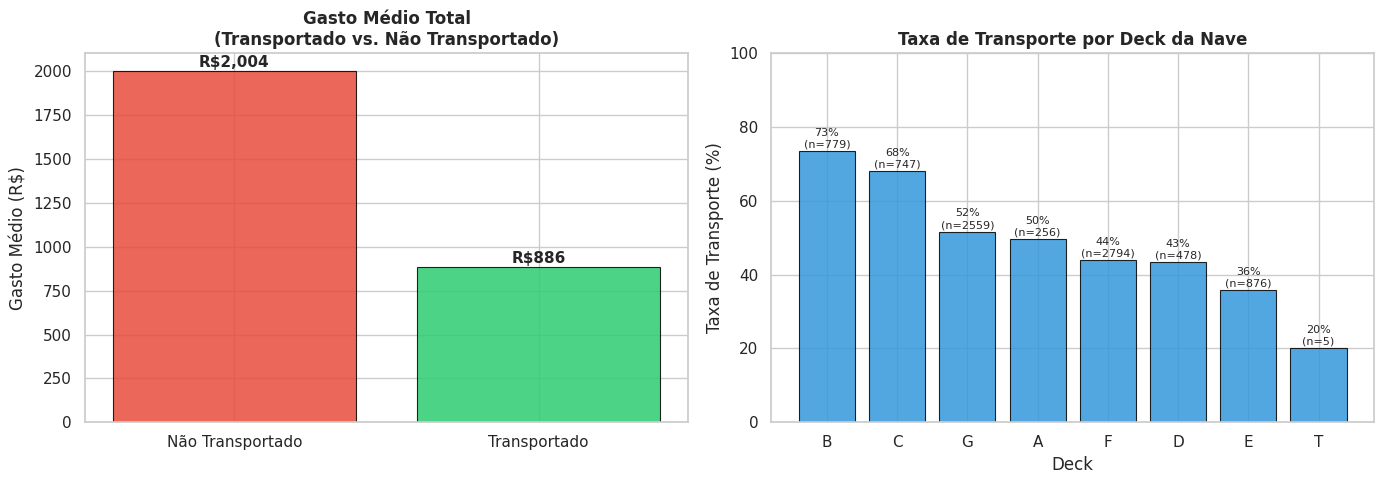

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gasto médio total por status de transporte
media_nao = train_eng.loc[train_eng['Transported'] == 0, 'TotalSpend'].mean()
media_sim = train_eng.loc[train_eng['Transported'] == 1, 'TotalSpend'].mean()

axes[0].bar(
    ['Não Transportado', 'Transportado'],
    [media_nao, media_sim],
    color=['#e74c3c', '#2ecc71'], edgecolor='black', linewidth=0.8, alpha=0.85
)
axes[0].set_title('Gasto Médio Total\n(Transportado vs. Não Transportado)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Gasto Médio (R$)')
for i, v in enumerate([media_nao, media_sim]):
    axes[0].text(i, v + 20, f'R${v:,.0f}', ha='center', fontsize=11, fontweight='bold')

# Taxa de transporte por deck da nave
deck_stats = (
    train_eng.groupby('Deck')['Transported']
    .agg(['mean', 'count'])
    .reset_index()
    .rename(columns={'mean': 'Taxa', 'count': 'Total'})
    .sort_values('Taxa', ascending=False)
)

barras = axes[1].bar(
    deck_stats['Deck'], deck_stats['Taxa'] * 100,
    color='#3498db', edgecolor='black', linewidth=0.8, alpha=0.85
)
axes[1].set_title('Taxa de Transporte por Deck da Nave', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Deck')
axes[1].set_ylabel('Taxa de Transporte (%)')
axes[1].set_ylim(0, 100)
# Mostrar total de passageiros em cada barra
for barra, total in zip(barras, deck_stats['Total']):
    h = barra.get_height()
    axes[1].text(barra.get_x() + barra.get_width() / 2, h + 1,
                f'{h:.0f}%\n(n={total})', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


Vemos que Passageiros não transportados gastam em média muito mais do que os transportados e que o Deck B/C (mais próximos da primeira classe Europa) têm maior taxa de transporte.

## 5. Pré-processamento dos Dados

Nesta etapa, transformamos o conjunto de dados em uma representação numérica compatível com os algoritmos de aprendizado de máquina. As transformações são encapsuladas em um `Pipeline` combinado com um `ColumnTransformer`, de modo que colunas numéricas e categóricas recebam tratamentos distintos de forma simultânea e organizada.

A utilizamos a `Pipeline` do scikit-learn por duas razões:

Primeira: garantir que o processo de aprendizado dos parâmetros de transformação (como a mediana de imputação ou os parâmetros de escalonamento) ocorra exclusivamente sobre os dados de treino, sendo depois aplicado ao conjunto de validação — prevenindo assim o *data leakage*.

Segunda: encapsular o pré-processamento e o modelo em um único objeto, tornando o código mais limpo e a validação cruzada mais rigorosa, já que cada fold é tratado de forma independente.

O quadro a seguir resume as transformações aplicadas a cada tipo de atributo.

| Passo | Atributos numéricos | Atributos categóricos |
|---|---|---|
| Imputação | Substituição pela **mediana** (robustez a *outliers*) | Substituição pela **moda** (categoria mais frequente) |
| Codificação | — | `OrdinalEncoder`: converte categorias em inteiros |
| Padronização | `StandardScaler`: µ = 0, σ = 1 | — |

A padronização é necessária para algoritmos sensíveis à escala dos atributos, como o KNN (que opera por distâncias euclidianas) e a Regressão Logística (cuja convergência é afetada por escalas distintas).


In [ ]:
# Separação entre matriz de atributos (X) e vetor-alvo (y)
X = train_eng.drop(columns=['Transported'])
y = train_eng['Transported'].astype(int)  # Conversão de booleano para inteiro (0/1)

# Definição dos conjuntos de colunas por tipo (categóricas ou numéricas)
cat_cols_proc = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
num_cols_proc = [c for c in X.columns if c not in cat_cols_proc]

print(f"X (atributos): {X.shape[0]:,} amostras × {X.shape[1]} colunas")
print(f"y (alvo)     : {y.shape[0]:,} valores")
print(f"\nColunas categóricas ({len(cat_cols_proc)}): {cat_cols_proc}")
print(f"Colunas numéricas   ({len(num_cols_proc)}): {num_cols_proc}")

# Pipeline para atributos numéricos:
# imputação de valores nulos pela mediana
# Padronizar média=0, desvio padrão=1
transformador_numerico = Pipeline(steps=[
    ('imputador',    SimpleImputer(strategy='median')),
    ('padronizador', StandardScaler())
])

# Pipeline para atributos categóricos:
# imputação de valores nulos pela moda
# codificação ordinal. Ex.: "Earth"=0, "Europa"=1, "Mars"=2
transformador_categorico = Pipeline(steps=[
    ('imputador',   SimpleImputer(strategy='most_frequent')),
    ('codificador', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# ColumnTransformer: aplica cada pipeline ao subconjunto de colunas correspondente
preprocessador = ColumnTransformer(transformers=[
    ('num', transformador_numerico,   num_cols_proc),
    ('cat', transformador_categorico, cat_cols_proc)
])

# Divisão estratificada treino/validação (80/20)
# stratify=y → mantém a proporção de classes nos dois subconjuntos
X_treino, X_val, y_treino, y_val = train_test_split(
    X, y, test_size=0.20, random_state=7, stratify=y
)

print(f"\nTreino   : {X_treino.shape[0]:,} amostras  ({y_treino.mean():.1%} transportados)")
print(f"Validação: {X_val.shape[0]:,} amostras   ({y_val.mean():.1%} transportados)")


X (atributos): 8,693 amostras × 17 colunas
y (alvo)     : 8,693 valores

Colunas categóricas (6): ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
Colunas numéricas   (11): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num', 'GroupSize', 'IsAlone', 'TotalSpend', 'HasSpending']

Treino   : 6,954 amostras  (50.4% transportados)
Validação: 1,739 amostras   (50.4% transportados)


## 6. Treinamento e Comparação dos Modelos

Nesta seção, treinamos e comparamos alguns classificadores estudados ao longo do curso e alguns extras. A descrição a seguir sintetiza o princípio de funcionamento e as características de cada algoritmo.

---

**Regressão Logística**

 O algoritmo modela a probabilidade da classe positiva por meio da função sigmoide aplicada a uma combinação linear dos atributos: σ(z) = 1 / (1 + e^(−z)). Sua principal vantagem é a interpretabilidade e a rapidez de treinamento; sua limitação é o pressuposto de linearidade na fronteira de decisão.

---

**Naive Bayes Gaussiano**

Classifica por meio do Teorema de Bayes: P(classe | dados) ∝ P(dados | classe) × P(classe). O qualificativo *naive* decorre do pressuposto de independência condicional entre os atributos, raramente satisfeito na prática, mas que ainda assim produz resultados razoáveis. A variante gaussiana assume que os atributos numéricos seguem distribuição normal dentro de cada classe. O Naive Bayes tende a ter um treinameto rápido e ser eficiente com poucos dados.

---

**Árvore de Decisão**

Constrói recursivamente uma estrutura de perguntas binárias sobre os atributos, particionando o espaço de atributos de forma a maximizar a homogeneidade de cada subconjunto resultante. Usa critérios como Gini (pelo o que pesquisamos, costuma ser mais rápido no cálculo computacional) ou Entropia para escolher a melhor pergunta em cada nível. A principal limitação é a tendência ao *overfitting*: árvores profundas memorizam o conjunto de treino sem generalizar bem.

---

**Random Forest**

Método de *ensemble* baseado em *bagging*: constrói N árvores de decisão independentes, cada uma treinada sobre uma amostra aleatória (com reposição) dos dados e um subconjunto aleatório dos atributos. A previsão final é determinada por votação majoritária. A aleatoriedade introduzida reduz a correlação entre as árvores e, consequentemente, a variância do modelo agregado. Tende a diminuir o *overfitting*, mas prejudica a facilidade de interpretação em relação a Árvore de Decisão.

---

**KNN (K Vizinhos Mais Próximos)**

Para cada instância de teste, identifica os K pontos mais próximos no espaço de atributos (segundo a distância euclidiana) e atribui a classe mais frequente entre eles. Por operar com distâncias, o algoritmo é altamente sensível à escala dos atributos, o que torna a padronização prévia indispensável.

---

**Gradient Boosting**

Método de *ensemble* baseado em *boosting*: constrói árvores de forma sequencial, sendo que cada nova árvore é ajustada sobre os resíduos (erros) da árvore anterior, na direção do gradiente da função de perda. Tende a produzir resultados superiores em dados tabulares, mas exige ajuste cuidadoso de hiperparâmetros para evitar *overfitting*.

---

### Estratégia de Avaliação: Validação Cruzada Estratificada (5-fold)

Em vez de avaliar cada modelo sobre uma única partição treino/validação — cujo resultado pode ser sensível à divisão específica dos dados —, adotamos a validação cruzada estratificada com 5 *folds*. O conjunto de treino é dividido em 5 subconjuntos de tamanho igual; em cada iteração, um subconjunto é reservado para validação e os quatro restantes são usados para treino. O processo se repete 5 vezes, cobrindo todos os subconjuntos. A acurácia final reportada é a média das 5 rodadas, acompanhada do desvio padrão como medida de estabilidade.

```
Fold 1: [TREINO | TREINO | TREINO | TREINO | VAL  ]  → acc₁
Fold 2: [TREINO | TREINO | TREINO | VAL   | TREINO] → acc₂
Fold 3: [TREINO | TREINO | VAL   | TREINO | TREINO] → acc₃
Fold 4: [TREINO | VAL   | TREINO | TREINO | TREINO] → acc₄
Fold 5: [VAL   | TREINO | TREINO | TREINO | TREINO] → acc₅
         Acurácia final = média(acc₁ … acc₅)
```

O qualificativo *estratificada* garante que a proporção entre classes seja preservada em cada fold, evitando que a variabilidade nos resultados seja atribuída ao desbalanceamento amostral.


In [ ]:
modelos = {
    'Regressão Logística' : LogisticRegression(max_iter=1000, random_state=7),
    'Naive Bayes'         : GaussianNB(),
    'Árvore de Decisão'   : DecisionTreeClassifier(random_state=7),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=7, n_jobs=-1),
    'KNN (K=5)'           : KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=7),
}

# Validação cruzada estratificada com 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

resultados_cv = {}

print("=== Validação Cruzada Estratificada (5 folds) ===")
print()
print(f"{'Modelo':<22} {'Média':>7} {'Desvio':>8} {'Mín':>7} {'Máx':>7}")
print("-" * 58)

for nome, modelo in modelos.items():
    # O pré-processador é incluído no pipeline para garantir que cada fold
    # seja transformado de forma independente, sem vazamento de informação
    pipe = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador',  modelo)
    ])

    # cross_val_score: executa o pipeline 5 vezes (um por fold)
    scores = cross_val_score(pipe, X_treino, y_treino,
                              cv=cv, scoring='accuracy', n_jobs=-1)
    resultados_cv[nome] = scores

    print(f"{nome:<22} {scores.mean():>7.4f} {scores.std():>8.4f} "
          f"{scores.min():>7.4f} {scores.max():>7.4f}")


=== Validação Cruzada Estratificada (5 folds) ===

Modelo                   Média   Desvio     Mín     Máx
----------------------------------------------------------
Regressão Logística     0.7854   0.0141  0.7705  0.8052
Naive Bayes             0.7307   0.0140  0.7115  0.7520
Árvore de Decisão       0.7542   0.0046  0.7469  0.7606
Random Forest           0.7982   0.0081  0.7908  0.8124
KNN (K=5)               0.7844   0.0054  0.7807  0.7951
Gradient Boosting       0.8000   0.0081  0.7901  0.8102


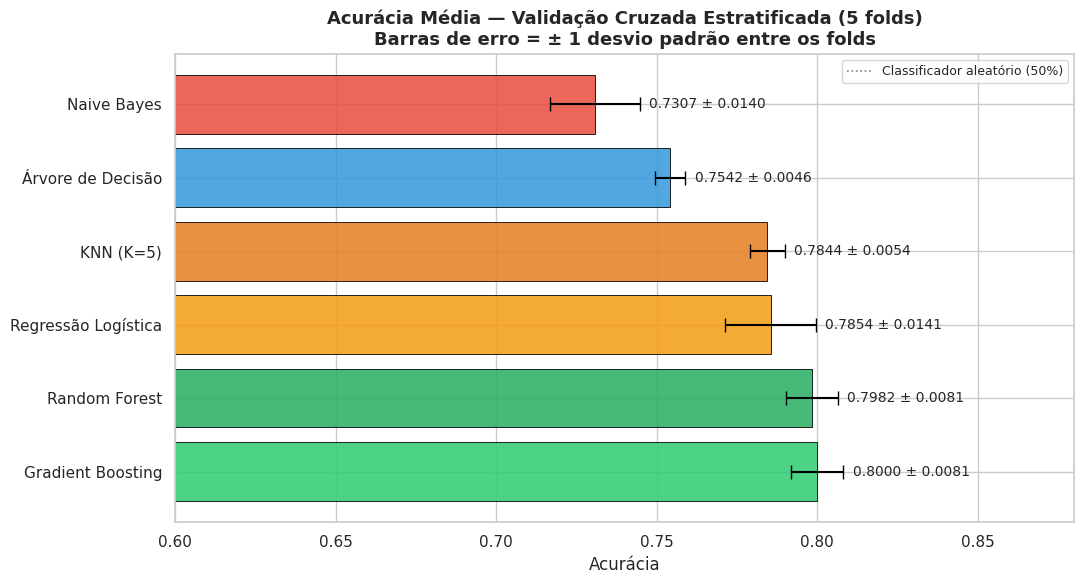

Melhor modelo na validação cruzada: Gradient Boosting
Acurácia média: 0.8000 (80.00%)


In [ ]:
# Ordenação decrescente dos modelos por acurácia média para facilitar a comparação visual
nomes   = list(resultados_cv.keys())
medias  = [resultados_cv[n].mean() for n in nomes]
desvios = [resultados_cv[n].std()  for n in nomes]

ordem = sorted(range(len(medias)), key=lambda i: medias[i], reverse=True)
nomes_ord  = [nomes[i]   for i in ordem]
medias_ord = [medias[i]  for i in ordem]
desv_ord   = [desvios[i] for i in ordem]

cores = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#3498db', '#e74c3c']

fig, ax = plt.subplots(figsize=(11, 6))

barras = ax.barh(nomes_ord, medias_ord, xerr=desv_ord,
                  color=cores, edgecolor='black', linewidth=0.7,
                  alpha=0.85, capsize=5, error_kw={'linewidth': 1.5})

ax.set_title('Acurácia Média — Validação Cruzada Estratificada (5 folds)\n'
             'Barras de erro = ± 1 desvio padrão entre os folds',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Acurácia')
ax.set_xlim(0.60, 0.88)

for barra, media, desvio in zip(barras, medias_ord, desv_ord):
    ax.text(media + desvio + 0.003, barra.get_y() + barra.get_height() / 2,
            f'{media:.4f} ± {desvio:.4f}', va='center', fontsize=10)

ax.axvline(x=0.50, color='gray', linestyle=':', linewidth=1.2, label='Classificador aleatório (50%)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

melhor_cv_nome = max(resultados_cv, key=lambda k: resultados_cv[k].mean())
melhor_cv_acc  = resultados_cv[melhor_cv_nome].mean()
print(f"Melhor modelo na validação cruzada: {melhor_cv_nome}")
print(f"Acurácia média: {melhor_cv_acc:.4f} ({melhor_cv_acc * 100:.2f}%)")


## 7. Otimização de Hiperparâmetros

### Definição

Hiperparâmetros são configurações do modelo definidas antes do treinamento — isto é, não são aprendidas a partir dos dados, mas escolhidas. Sua seleção inadequada pode resultar em *underfitting* (modelo excessivamente simples) ou *overfitting* (modelo excessivamente complexo). A tabela a seguir lista alguns hiperparâmetros.

| Modelo | Hiperparâmetro | Efeito |
|---|---|---|
| Random Forest | `n_estimators` | Número de árvores; valores maiores aumentam a estabilidade, mas elevam o custo computacional |
| Random Forest | `max_depth` | Profundidade máxima de cada árvore; limita o *overfitting* |
| Random Forest | `min_samples_split` / `min_samples_leaf` | Controla a granularidade das divisões; valores maiores simplificam o modelo |
| Gradient Boosting | `learning_rate` | Taxa de contribuição de cada árvore; valores menores exigem mais iterações |
| Gradient Boosting | `n_estimators` | Número de iterações de *boosting* |
| Gradient Boosting | `subsample` | Fração dos dados usada em cada iteração; valores < 1 introduzem aleatoriedade e reduzem *overfitting* |
| KNN | `n_neighbors` | Vizinhos considerados; altera o equilíbrio entre o viés e a variância

### Estratégia: `RandomizedSearchCV`

Em vez de avaliar todas as combinações possíveis (*grid search* exaustivo), optamos por `RandomizedSearchCV`, que amostra aleatoriamente `n_iter` combinações do espaço de busca. Essa abordagem reduz substancialmente o custo computacional com perda marginal de qualidade, uma vez que o espaço de hiperparâmetros raramente é explorado de forma uniforme e muitas combinações são subótimas. Em ambos os modelos, a avaliação de cada combinação é realizada com a mesma validação cruzada estratificada de 5 *folds* definida anteriormente.


In [ ]:
# Definimos o espaço de busca: quais valores cada hiperparâmetro pode assumir
# Espaço de busca para Random Forest
espaco_rf = {
    'classificador__n_estimators'      : [100, 200, 300, 500],
    # None = sem limite (pode levar a overfitting)
    'classificador__max_depth'         : [None, 10, 20, 30],
    # min_samples_split: mínimo de amostras para dividir um nó
    # Valores maiores → árvores mais simples → menos overfitting
    'classificador__min_samples_split' : [2, 5, 10],
    'classificador__min_samples_leaf'  : [1, 2, 4],
    # 'sqrt' limita o número de atributos por divisão, reduzindo a correlação entre árvores
    'classificador__max_features'      : ['sqrt', 'log2'],
}

pipe_rf = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('classificador',  RandomForestClassifier(random_state=7, n_jobs=-1))
])

busca_rf = RandomizedSearchCV(
    pipe_rf,
    espaco_rf,
    n_iter=25,            # Testar 25 combinações aleatórias
    cv=cv,                # Mesma validação cruzada estratificada (5 folds)
    scoring='accuracy',
    random_state=7,
    n_jobs=-1,
    verbose=1
)

busca_rf.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros (Random Forest):")
for param, valor in sorted(busca_rf.best_params_.items()):
    print(f"  {param.replace('classificador__','')}: {valor}")
print(f"\nAcurácia média (CV): {busca_rf.best_score_:.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Melhores hiperparâmetros (Random Forest):
  max_depth: 20
  max_features: sqrt
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 500

Acurácia média (CV): 0.8034


In [ ]:
# Espaço de busca para Gradient Boosting
espaco_gb = {
    # n_estimators: número de árvores (iterações de boosting)
    'classificador__n_estimators'     : [100, 200, 300],
    # Taxa de aprendizado: controla a contribuição de cada árvore sequencial
    # Menor = aprende mais devagar mas pode ser mais preciso
    'classificador__learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    # Gradient Boosting opera com árvores rasas (3–6 níveis), diferentemente do Random Forest
    'classificador__max_depth'        : [3, 4, 5, 6],
    # Subamostragem estocástica: reduz overfitting ao introduzir variabilidade por iteração
    'classificador__subsample'        : [0.7, 0.8, 0.9, 1.0],
    'classificador__min_samples_split': [2, 5, 10],
}

pipe_gb = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('classificador',  GradientBoostingClassifier(random_state=7))
])

busca_gb = RandomizedSearchCV(
    pipe_gb,
    espaco_gb,
    n_iter=25,
    cv=cv,
    scoring='accuracy',
    random_state=13,
    n_jobs=-1,
    verbose=1
)

busca_gb.fit(X_treino, y_treino)

print(f"\nMelhores hiperparâmetros (Gradient Boosting):")
for param, valor in sorted(busca_gb.best_params_.items()):
    print(f"  {param.replace('classificador__','')}: {valor}")
print(f"\nAcurácia média (CV): {busca_gb.best_score_:.4f}")


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Melhores hiperparâmetros (Gradient Boosting):
  learning_rate: 0.05
  max_depth: 4
  min_samples_split: 10
  n_estimators: 300
  subsample: 0.9

Acurácia média (CV): 0.8079


In [ ]:
# Avaliação de todos os modelos no conjunto de validação (dados não utilizados no treino)
print("=== Desempenho no Conjunto de Validação ===")
print()

# Modelos base (sem otimização)
todos_modelos = {}
for nome, modelo in modelos.items():
    pipe = Pipeline(steps=[
        ('preprocessador', preprocessador),
        ('classificador',  modelo)
    ])
    pipe.fit(X_treino, y_treino)
    todos_modelos[nome] = pipe

# Adicionar modelos otimizados
todos_modelos['Random Forest (otimizado)']     = busca_rf.best_estimator_
todos_modelos['Gradient Boosting (otimizado)'] = busca_gb.best_estimator_

# Calculo de métricas para cada modelo
resultados_val = {}
print(f"{'Modelo':<35} {'Acurácia':>10} {'AUC-ROC':>9}")
print("-" * 57)

for nome, pipe in todos_modelos.items():
    y_pred = pipe.predict(X_val)
    acc    = accuracy_score(y_val, y_pred)
    try:
        y_prob = pipe.predict_proba(X_val)[:, 1]
        auc    = roc_auc_score(y_val, y_prob)
    except:
        auc = float('nan')
    resultados_val[nome] = {'acuracia': acc, 'auc': auc, 'pipeline': pipe}
    print(f"{nome:<35} {acc:>10.4f} {auc:>9.4f}")

# Melhor modelo
melhor_val_nome = max(resultados_val, key=lambda k: resultados_val[k]['acuracia'])
melhor_val_acc  = resultados_val[melhor_val_nome]['acuracia']
print()
print(f"Melhor modelo no conjunto de validação: {melhor_val_nome}")
print(f"Acurácia: {melhor_val_acc:.4f} ({melhor_val_acc * 100:.2f}%)")


=== Desempenho no Conjunto de Validação ===

Modelo                                Acurácia   AUC-ROC
---------------------------------------------------------
Regressão Logística                     0.8028    0.8814
Naive Bayes                             0.7504    0.8507
Árvore de Decisão                       0.7545    0.7548
Random Forest                           0.8028    0.8906
KNN (K=5)                               0.7780    0.8511
Gradient Boosting                       0.8108    0.9029
Random Forest (otimizado)               0.7993    0.8996
Gradient Boosting (otimizado)           0.8177    0.9100

Melhor modelo no conjunto de validação: Gradient Boosting (otimizado)
Acurácia: 0.8177 (81.77%)


## 8. Análise Detalhada do Melhor Modelo

### 8.1 Relatório de Classificação e Matriz de Confusão

A matriz de confusão organiza as previsões do modelo em quatro categorias:

```
                      Previsto: Não Transp.    Previsto: Transp.
Real: Não Transp.     Verdadeiro Negativo (VN)  Falso Positivo (FP)
Real: Transp.         Falso Negativo (FN)       Verdadeiro Positivo (VP)
```

As métricas derivadas da matriz são:

- **Precisão** = VP / (VP + FP): dos passageiros previstos como transportados, qual proporção de fato o foi?
- **Recall (Sensibilidade)** = VP / (VP + FN): dos passageiros que de fato foram transportados, qual proporção o modelo identificou corretamente?
- **F1-Score**: média harmônica entre precisão e recall, útil quando há trade-off entre ambas.

A **Curva ROC** ilustra a relação entre a taxa de verdadeiros positivos (recall) e a taxa de falsos positivos para diferentes limiares de decisão. A **AUC-ROC** (área sob a curva) varia de 0,5 — equivalente a um classificador aleatório — a 1,0, correspondente à classificação perfeita. Valores acima de 0,80 são geralmente considerados bons para problemas reais.


=== Relatório de Classificação — Gradient Boosting (otimizado) ===

                  precision    recall  f1-score   support

Não Transportado       0.82      0.82      0.82       863
    Transportado       0.82      0.82      0.82       876

        accuracy                           0.82      1739
       macro avg       0.82      0.82      0.82      1739
    weighted avg       0.82      0.82      0.82      1739



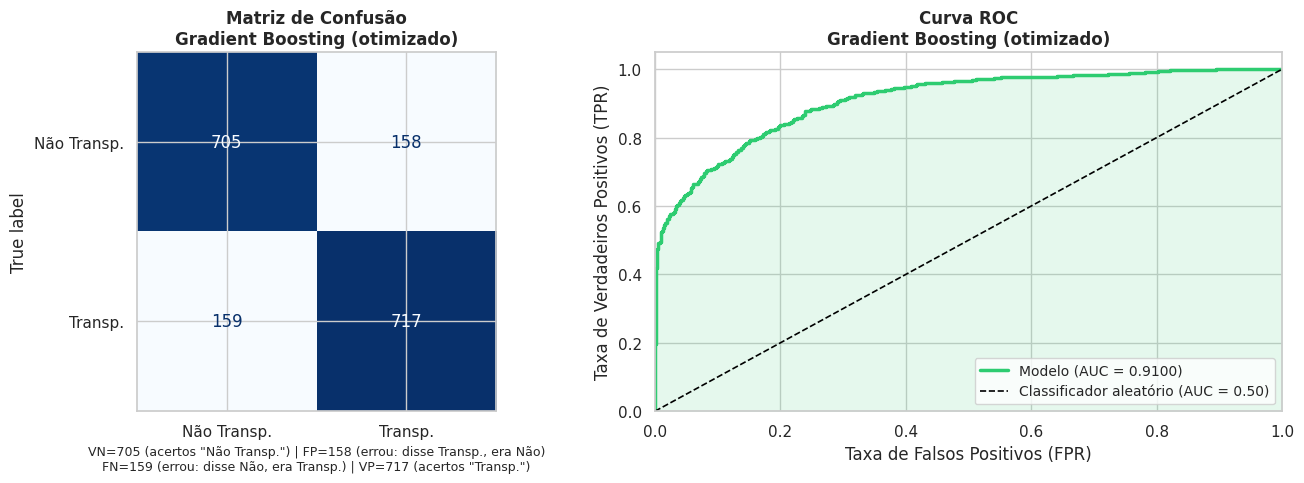


Resumo das métricas no conjunto de validação:
  Acurácia : 81.77%
  AUC-ROC  : 0.9100


In [ ]:
melhor_pipe   = resultados_val[melhor_val_nome]['pipeline']
y_pred_melhor = melhor_pipe.predict(X_val)
y_prob_melhor = melhor_pipe.predict_proba(X_val)[:, 1]

print(f"=== Relatório de Classificação — {melhor_val_nome} ===\n")
print(classification_report(
    y_val, y_pred_melhor,
    target_names=['Não Transportado', 'Transportado']
))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão
cm = confusion_matrix(y_val, y_pred_melhor)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Não Transp.', 'Transp.']
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusão\n{melhor_val_nome}', fontsize=12, fontweight='bold')

vn, fp, fn, vp = cm.ravel()
axes[0].set_xlabel(
    f'VN={vn} (acertos "Não Transp.") | FP={fp} (errou: disse Transp., era Não)\n'
    f'FN={fn} (errou: disse Não, era Transp.) | VP={vp} (acertos "Transp.")',
    fontsize=9
)

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_prob_melhor)
auc_val      = roc_auc_score(y_val, y_prob_melhor)

axes[1].plot(fpr, tpr, color='#2ecc71', linewidth=2.5,
             label=f'Modelo (AUC = {auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Classificador aleatório (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='#2ecc71')
axes[1].set_title(f'Curva ROC\n{melhor_val_nome}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[1].legend(fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

print(f"\nResumo das métricas no conjunto de validação:")
print(f"  Acurácia : {accuracy_score(y_val, y_pred_melhor) * 100:.2f}%")
print(f"  AUC-ROC  : {auc_val:.4f}")


### 8.2 Importância dos Atributos

Modelos baseados em árvores de decisão — como Random Forest e Gradient Boosting — calculam a importância de cada atributo durante o treinamento. Essa métrica quantifica, em média, o quanto cada atributo contribui para a redução da impureza (índice de Gini ou entropia) nas divisões de todas as árvores do ensemble. Atributos com importância elevada são os que, com maior frequência e em maior grau, separam as classes nas partições do espaço de atributos.

Essa análise nos permite: (a) validar as hipóteses formuladas na etapa de engenharia de atributos, verificando se os novos atributos criados se mostraram relevantes para o modelo; e (b) identificar candidatos à remoção em um eventual processo de seleção de atributos.


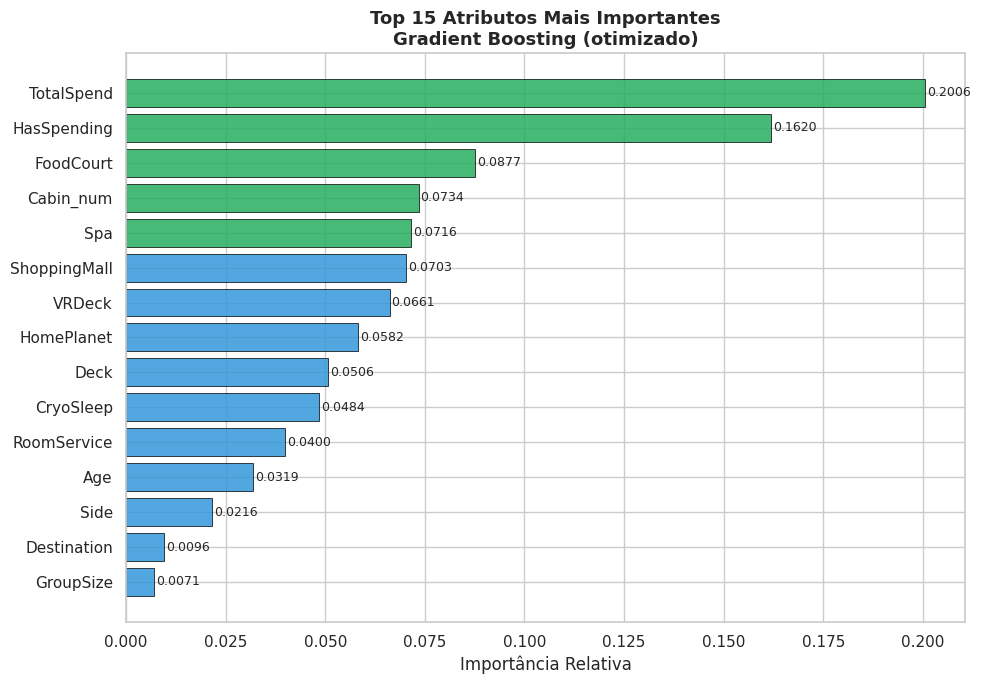


Top 5 atributos mais importantes:
  TotalSpend          : 0.2006 (20.06%)
  HasSpending         : 0.1620 (16.20%)
  FoodCourt           : 0.0877 (8.77%)
  Cabin_num           : 0.0734 (7.34%)
  Spa                 : 0.0716 (7.16%)


In [ ]:
# Extrair o classificador do pipeline
classificador_final = melhor_pipe.named_steps['classificador']

# Verificar se o modelo tem importância de features (atributos)
if hasattr(classificador_final, 'feature_importances_'):
    importancias = classificador_final.feature_importances_

    # Nomes das features após transformação pelo ColumnTransformer
    nomes_features = num_cols_proc + cat_cols_proc

    df_imp = pd.DataFrame({
        'Feature'     : nomes_features,
        'Importância' : importancias
    }).sort_values('Importância', ascending=True)

    # Mostrar as 15 mais importantes
    top_n = min(15, len(df_imp))
    top_df = df_imp.tail(top_n)

    fig, ax = plt.subplots(figsize=(10, 7))

    # Destaque visual para os atributos acima do percentil 70 de importância
    limite_destaque = df_imp['Importância'].quantile(0.70)
    cores_imp = ['#27ae60' if v > limite_destaque else '#3498db'
                 for v in top_df['Importância']]

    ax.barh(top_df['Feature'], top_df['Importância'],
            color=cores_imp, edgecolor='black', linewidth=0.6, alpha=0.85)
    ax.set_title(f'Top {top_n} Atributos Mais Importantes\n{melhor_val_nome}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importância Relativa')

    for i, (feat, imp) in enumerate(zip(top_df['Feature'], top_df['Importância'])):
        ax.text(imp + 0.0005, i, f'{imp:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nTop 5 atributos mais importantes:")
    for i, row in df_imp.tail(5).iloc[::-1].iterrows():
        print(f"  {row['Feature']:<20}: {row['Importância']:.4f} ({row['Importância']*100:.2f}%)")
else:
    print(f"O modelo {melhor_val_nome} não disponibiliza importância de atributos diretamente.")
    print("Isso ocorre com Naive Bayes, KNN e Regressão Logística.")


## 9. Geração do Arquivo de Submissão

Nesta etapa final, aplicamos o modelo selecionado ao conjunto de teste para gerar as previsões a serem submetidas à competição Kaggle. O processo segue três passos:

1. **Re-treinamento com o conjunto completo de treino**: até este ponto, utilizamos apenas 80% dos dados rotulados para treinar os modelos, reservando 20% para validação. Agora que o melhor modelo e seus hiperparâmetros foram definidos, re-treinamos o pipeline com a totalidade dos dados rotulados disponíveis (100%), maximizando a informação absorvida pelo modelo antes da inferência no conjunto de teste.

2. **Aplicação das transformações ao conjunto de teste**: o conjunto `test_eng`, já processado pela função de engenharia de atributos, é submetido ao pipeline, que aplica automaticamente as mesmas transformações de pré-processamento aprendidas no treino.

3. **Geração do arquivo de saída**: as previsões, convertidas de inteiro (0/1) para booleano (`False`/`True`), são salvas no formato CSV esperado pela competição.

É fundamental que as transformações aplicadas ao teste sejam exatamente as mesmas que as do treino. O uso do `Pipeline` garante isso por construção, uma vez que os parâmetros de imputação e escalonamento são armazenados no objeto ajustado e reutilizados sem necessidade de recalculá-los.


In [ ]:
# Re-treinamento com a totalidade dos dados de treino rotulados
melhor_pipe.fit(X, y)

# Preservação dos identificadores de passageiro para o arquivo de submissão
# test_eng já foi criado anteriormente pela função feature_engineering()
ids_submissao = test_df['PassengerId']
X_teste = test_eng

# Inferência sobre o conjunto de teste
previsoes_num  = melhor_pipe.predict(X_teste)
previsoes_bool = previsoes_num.astype(bool)

print(f"Distribuição das previsões no conjunto de teste:")
print(f"  Transportados     : {previsoes_num.sum():,} ({previsoes_num.mean()*100:.1f}%)")
print(f"  Não transportados : {(1-previsoes_num).sum():,} ({(1-previsoes_num).mean()*100:.1f}%)")

# Construção do DataFrame de submissão no formato exigido pela competição
submissao = pd.DataFrame({
    'PassengerId': ids_submissao,
    'Transported': previsoes_bool
})

print("\n=== Primeiras linhas do arquivo de submissão ===")
print(submissao.head(10).to_string(index=False))

# Persistência do arquivo no diretório do projeto
caminho_saida = f"{BASE_PATH}/submission.csv"
#caminho_saida = f"submission.csv"
submissao.to_csv(caminho_saida, index=False)

print(f"\nArquivo salvo em: {caminho_saida}")
print(f"Dimensões: {submissao.shape[0]:,} linhas × {submissao.shape[1]} colunas")


Distribuição das previsões no conjunto de teste:
  Transportados     : 2,208 (51.6%)
  Não transportados : 2,069 (48.4%)

=== Primeiras linhas do arquivo de submissão ===
PassengerId  Transported
    0013_01         True
    0018_01        False
    0019_01         True
    0021_01         True
    0023_01         True
    0027_01         True
    0029_01         True
    0032_01         True
    0032_02         True
    0033_01         True

Arquivo salvo em: /content/drive/MyDrive/Mineração de Dados/Trabalho_Elian_Hugo/spaceship-titanic/submission.csv
Dimensões: 4,277 linhas × 2 colunas


## 10. Conclusão

### Síntese do Projeto

A tabela a seguir resume as decisões tomadas em cada etapa do projeto, bem como a justificativa que as fundamenta.

| Etapa | Procedimento adotado | Justificativa |
|---|---|---|
| Análise exploratória | Distribuições, valores ausentes, testes χ² | Fundamentar as decisões de pré-processamento e engenharia de atributos em evidências estatísticas |
| Engenharia de atributos | Decomposição de `Cabin`, `TotalSpend`, `HasSpending`, `GroupSize` | Tornar explícitas informações estruturais e comportamentais não capturadas diretamente pelos atributos brutos |
| Pré-processamento | Imputação, codificação ordinal e padronização via `Pipeline` | Garantir consistência entre treino e teste e prevenir *data leakage* |
| Comparação de modelos | Validação cruzada estratificada (5 *folds*) sobre 6 classificadores | Selecionar o algoritmo com base em estimativa robusta do desempenho de generalização |
| Otimização | `RandomizedSearchCV` nos dois melhores modelos | Maximizar o desempenho sem o custo computacional da busca exaustiva |
| Análise do modelo final | Matriz de confusão, curva ROC e importância de atributos | Diagnosticar os erros do modelo e validar as hipóteses levantadas na EDA |
| Submissão | Re-treinamento com 100% dos dados rotulados e inferência no conjunto de teste | Maximizar a informação utilizada na fase de produção |

### Principais Concluções

1. O atributo `CryoSleep` é o preditor mais relevante: passageiros em estado criogênico apresentam aproximadamente 81% de probabilidade de terem sido transportados, conforme evidenciado pelo teste χ² com o maior valor de qui-quadrado.
2. Os atributos de gasto (`RoomService`, `FoodCourt`, `Spa` etc.) funcionam como indicadores indiretos do estado criogênico — passageiros em *CryoSleep* não podem consumir serviços, resultando em gasto nulo.
3. Modelos de *ensemble* (Random Forest e Gradient Boosting) superaram consistentemente os modelos lineares e o KNN, o que era esperado dado que os dados apresentam relações não-lineares complexas entre os atributos.
4. A engenharia de atributos, em particular a criação de `TotalSpend` e `HasSpending`, contribuiu para o desempenho final, como confirmado pela análise de importância de atributos do modelo vencedor.

### Desempenho Qualitativo por Classificador

| Classificador | Desempenho observado | Causa principal |
|---|---|---|
| Regressão Logística | Intermediário | Pressuposto de linearidade não satisfeito |
| Naive Bayes | Intermediário-baixo | Pressuposto de independência condicional violado |
| Árvore de Decisão | Intermediário | *Overfitting* com árvore única não podada |
| Random Forest | **Alto** | Redução de variância via *bagging* e aleatoriedade nos atributos |
| KNN | Intermediário | Sensível à dimensionalidade e ao escalonamento |
| Gradient Boosting | **Alto** | Correção iterativa de erros via *boosting* sequencial |
